## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.parameter_dependence import ParametersAxionMassDependence

## Initialization and Analysis of Axion Parameter Dependence

In this notebook, we analyze the dependence of parameters **A(m_a)**, **b(m_a)**, and **μ(m_a)** on axion mass **m_a** 
after selecting a specific axion production channel. The goal is to fit functions to describe these dependencies and evaluate their accuracy.

#### **Key Observations:**
1. **Polynomial Fit Behavior:**
   - The polynomial fits **A(log(m_a))**, **b(log(m_a))**, and **μ(log(m_a))** work well **within the provided mass range**:  
     **[0.0623 eV, 6.23 eV]** (as given by Maxim's distribution data).  
   - However, **extrapolation beyond this range is highly unreliable**. The polynomial fit becomes unstable and produces unrealistic values.
2. **Function-Based Fit (Model-Driven Approach):**
   - We implement model-based fitting functions to mimic the observed behavior of the parameters.  
   - However, some challenges remain:
     - The **μ(m_a) dependence** shows discrepancies that require further investigation.
     - The **A(m_a) fit struggles at larger masses**, especially outside the provided dataset range.
     - Possible **plateau effects** appear, but distinguishing them from numerical artifacts requires deeper analysis.

#### **Next Steps:**
- Validate function-based fits with alternative datasets.
- Investigate possible **physical constraints** that could guide extrapolation.
- Assess whether alternative parameterizations offer improved stability.

In [3]:
file_path = '../Maxim-data/ma_distributions_mu_scattering.dat'  # Set the correct file path
parameterDependence = ParametersAxionMassDependence("muon_scattering", file_path)

## Distribution: $f(q)\cdot q^3$

In [4]:
# --- DISTRIBUTION: f(q)*q^3 ---
distribution = "f(q)_q3"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -3.00  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [-3.01005751e-05 -1.99188337e-04 -9.90525413e-05  1.77532435e-03
  2.86818680e-03 -5.67666454e-03 -1.43649271e-02  7.70876772e-03
  3.83215927e-02 -7.09298418e-03 -1.06364371e-01  1.14416365e+00]
Polynomial fit coefficients for b: [-1.95649813e-04 -9.33928178e-04  1.54326800e-03  1.20335771e-02
 -1.09508491e-03 -6.41485333e-02 -2.64004409e-02  2.00928032e-01
  1.37552237e-01 -6.71769531e-01  5.21061359e-01 -5.18357965e-02]
Polynomial fit coefficients for μ: [ 1.64083946e-04 -2.25599779e-03  9.92920697e-04  2.29987179e-02
  2.08748982e-02 -2.55531374e-01  3.24438777e-01 -2.97201188e-01
  1.31849234e+00 -2.48643030e+00  1.74900289e+00 -2.60025251e+00]


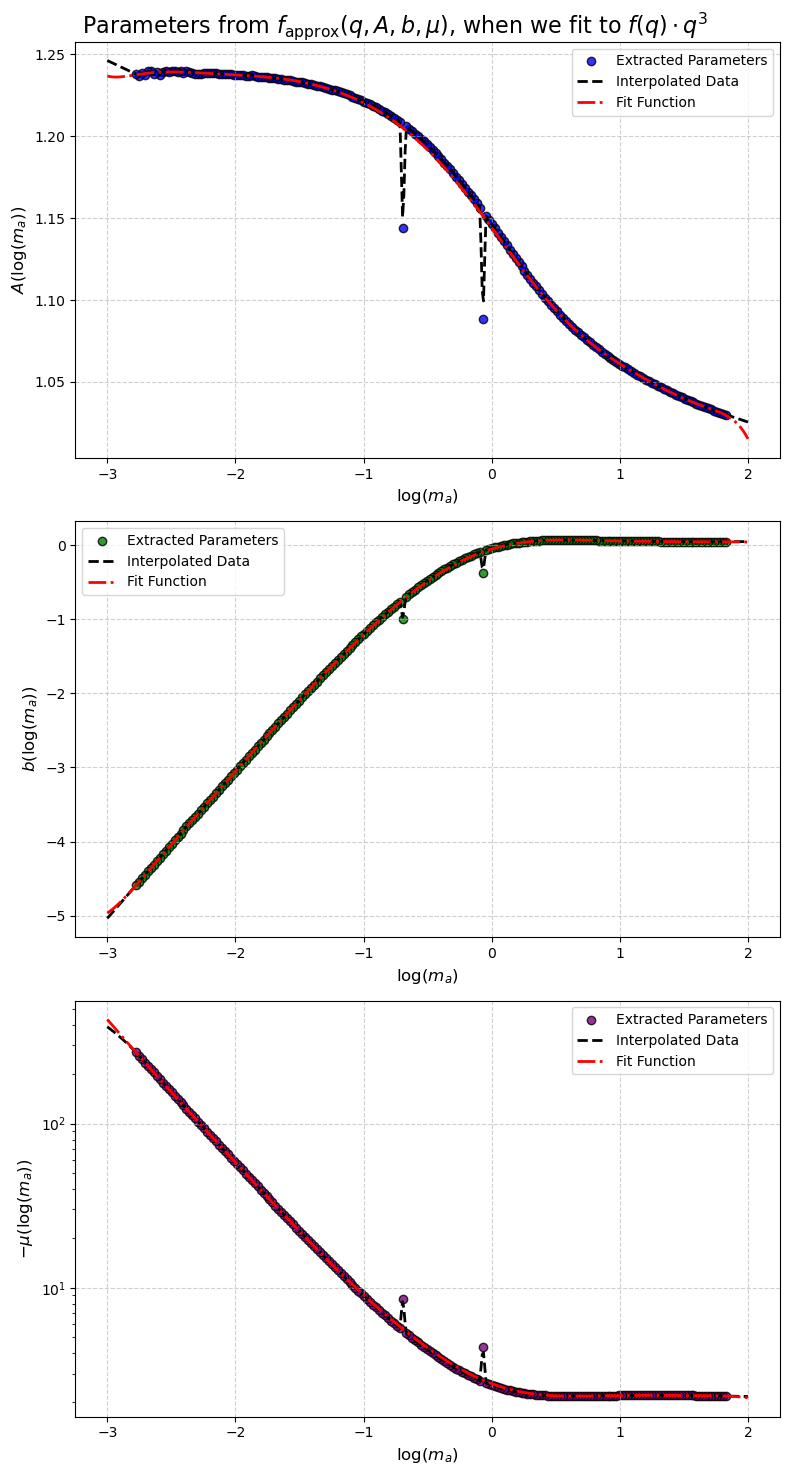

In [5]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q^3$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)\cdot q^2$

In [6]:
# --- DISTRIBUTION: f(q)*q^2 ---
distribution = "f(q)_q2"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -3.00  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [-2.86063803e-05 -2.69799110e-04 -5.17166975e-04  1.91388372e-03
  6.64291681e-03 -3.58895695e-03 -2.76759519e-02 -1.82558394e-03
  6.22438714e-02  8.02587869e-03 -1.38904014e-01  1.12831659e+00]
Polynomial fit coefficients for b: [-2.18517724e-04 -1.36453392e-03 -3.36731798e-08  1.41375347e-02
  1.44209933e-02 -6.21440130e-02 -8.28085221e-02  1.75891212e-01
  2.38510373e-01 -6.26592196e-01  3.90659728e-01 -1.09645635e-01]
Polynomial fit coefficients for μ: [ 7.85008268e-04  1.14985041e-03 -5.16498990e-03 -1.53589708e-02
  5.02540035e-02 -7.84486470e-02  1.78973632e-01 -5.66151799e-01
  1.48061388e+00 -2.08054671e+00  1.29694376e+00 -2.81321784e+00]


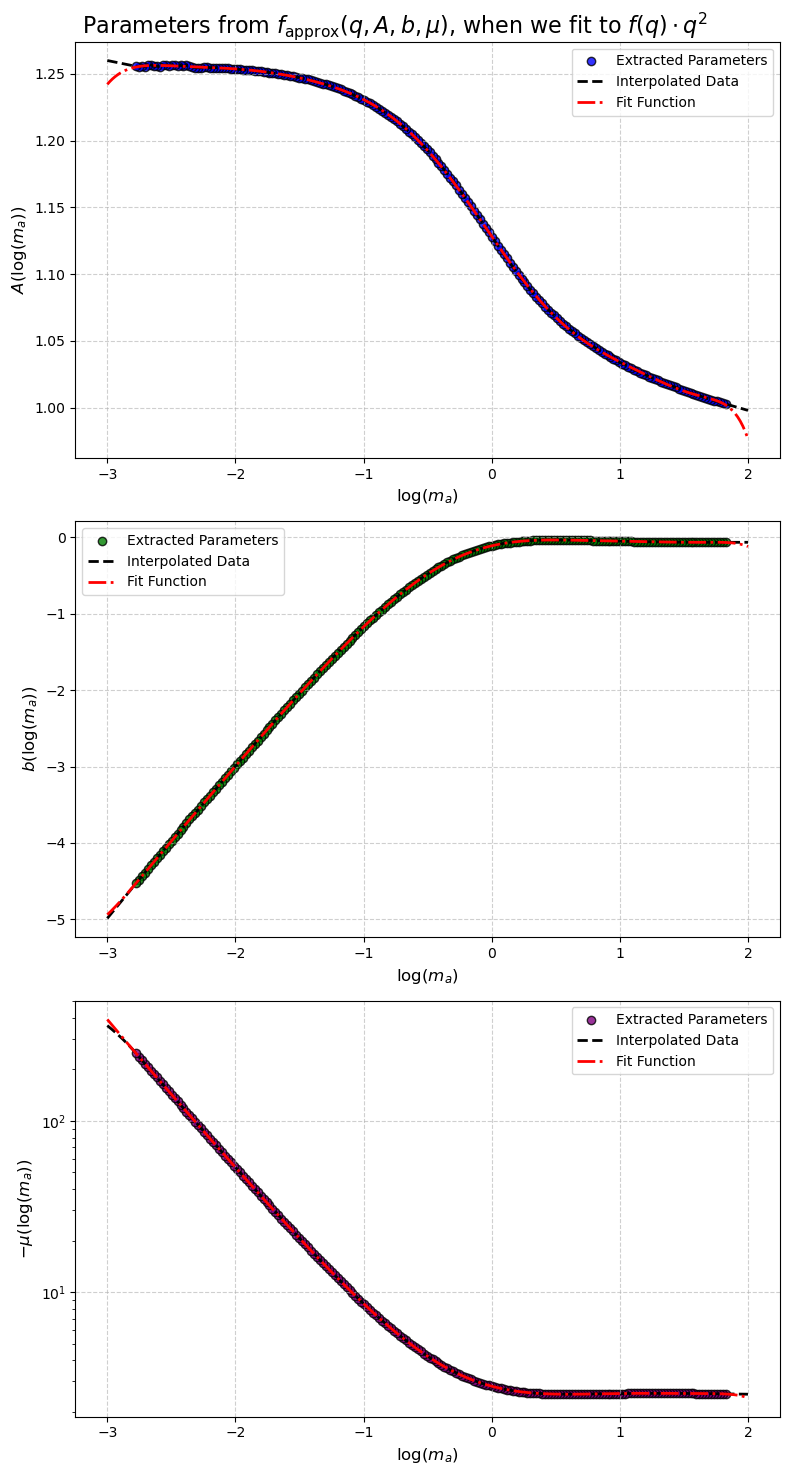

In [7]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q^2$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)\cdot q$

In [8]:
# --- DISTRIBUTION: f(q)*q ---
distribution = "f(q)_q1"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -3.00  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [-9.55669043e-05 -7.80887629e-04 -1.15764811e-03  5.71284930e-03
  1.62818650e-02 -1.14813070e-02 -6.59113354e-02 -3.69502676e-03
  1.33030038e-01  2.65724981e-02 -2.50275925e-01  9.45348823e-01]
Polynomial fit coefficients for b: [-5.13624143e-04 -3.46926371e-03 -1.98557672e-03  3.07367051e-02
  4.92421877e-02 -1.03258324e-01 -2.24367195e-01  1.97160170e-01
  5.00208151e-01 -5.97545215e-01 -1.56783959e-02 -6.82040145e-01]
Polynomial fit coefficients for μ: [ 5.23626961e-04 -2.20526951e-03 -1.18548834e-02  1.11421359e-02
  1.47334782e-01 -1.81489723e-01 -1.31317746e-01 -6.32600255e-01
  2.51086132e+00 -2.67281965e+00  6.54312865e-01 -4.67945677e+00]


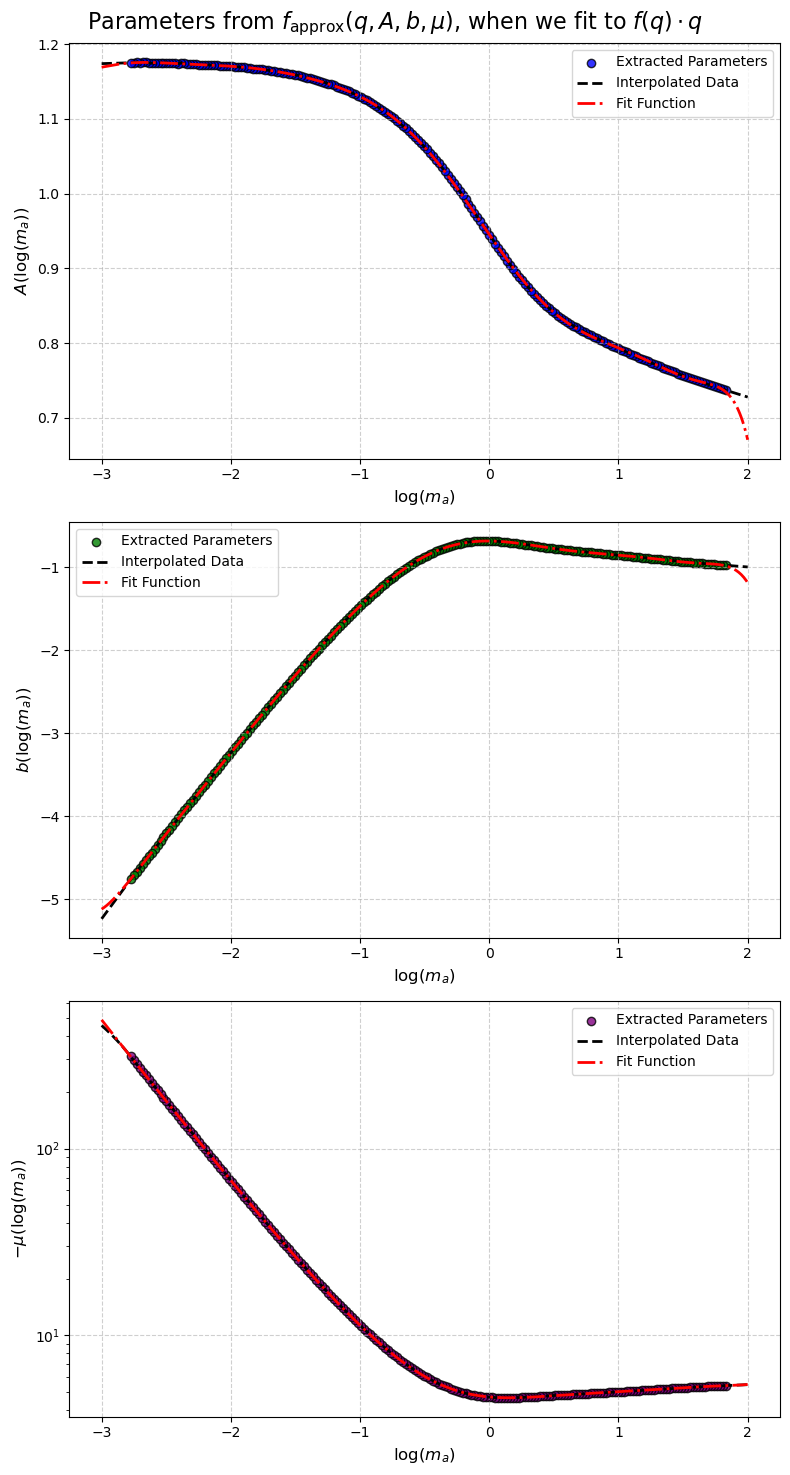

In [9]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)$

For now It does not work. But we do not have to take about. It just means, if we take f(q)*q^2 and multiply by q^(-2).
So in the end we will have f(q) and then we want comapre this to f_approx(q, A, b, mu) this comparison it not stable.
But the other is stable. We firstly compare f(q)*q^2 with f_approx(q, A, b, mu)*q^2 and then we multiply by q^(-2) and then
we obtain sth similar comparable with f(q).

In [10]:
# --- DISTRIBUTION: f(q) ---
distribution = "f(q)"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -3.00  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [ ]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    if name_of_parameters[i] == "mu":
        ax.scatter(log_m_arr_input, (-1)*points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')
    else:
        ax.scatter(log_m_arr_input, points_param[i],
                    color=colors[i], marker='o', edgecolors='black',
                    alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, (-1)*interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')
    else:
        ax.plot(log_m_arr_set, interpolated_param[i],
                 linestyle='--', linewidth=2, color='black',
                 label='Interpolated Data')


    # Plot fitted function for the parameter
    if name_of_parameters[i] == "mu":
        ax.plot(log_m_arr_set, 
                (-1)*parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                                    log_m_arr_set,
                                                                    "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    else:
        ax.plot(log_m_arr_set, 
                parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                               log_m_arr_set,
                                                               "test_polynomial"),  # test_polynomial, test_fit
                 linestyle='-.', linewidth=2, color='red',
                 label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

    # Set log scale only for the y-axis of μ(m_a)
    if name_of_parameters[i] == "mu":
        plt.yscale("log")

# Adjust layout
plt.tight_layout()
plt.show()